# Generowanie opisów obrazów – Show and Tell (2014)

Projekt realizowany w ramach przedmiotu _Analiza danych obrazowych i multimedialnych_.  
**Zespół projektowy:** Michał Suchocki, Piotr Szczerba, Krzysztof Rudnik, Krzysztof Dąbrowski  
**Realizacja:** 2026-06-02

<a href="https://github.com/christopher-dabrowski/Show-and-Tell" target="_blank" rel="noopener noreferrer">
  <div style="display:inline-flex; align-items:center; gap:8px;">
    <img src="https://github.githubassets.com/images/modules/logos_page/GitHub-Mark.png" alt="GitHub" width="16" style="vertical-align:middle;" />
    Repozytorium
    <img alt="GitHub commits since tagged version" src="https://img.shields.io/github/commits-since/christopher-dabrowski/Show-and-Tell/forked?style=for-the-badge">
  </div>
</a>


# Spis treści
<!-- TODO: Uzupełnić spis treści na koniec -->

- [Omówienie metody Show and Tell](#omowienie-metody-show-and-tell)
- [Omówienie wykorzystanej implementacji](#omowienie-wykorzystanej-implementacji)
- [Wyniki działania](#wyniki-dzialania)
- [Krytyczna analiza](#krytyczna-analiza)
- [Wnioski](#wnioski)

# Omówienie metody Show and Tell
<!-- krótko, zwięźle: do czego słuzy, na czym polega, podać linki do bardziej szczegółowych omówień, tutoriali, do repozytoriów kodu -->

Model Show and Tell jest jednym z pierwszych skutecznych podejść do **automatycznego generowania opisów tekstowych na podstawie obrazów**. Architektura **łączy sieć konwolucyjną**, która pełni rolę ekstraktora cech wizualnych, **z siecią rekurencyjną** odpowiedzialną za generowanie sekwencji słów opisujących obraz.
Wektor cech obrazu jest wykorzystywany jako wejście modelu językowego, który przewiduje kolejne słowa opisu w sposób sekwencyjny. Dzięki temu możliwe jest automatyczne tworzenie zdań opisujących zawartość sceny, obecne obiekty oraz relacje między nimi. Model został wytrenowany na dużych zbiorach zawierających obrazy wraz z opisami tekstowymi, co pozwoliło mu nauczyć się powiązań między reprezentacją wizualną a językiem naturalnym. Podejście to zapoczątkowało intensywny rozwój metod multimodalnych łączących analizę obrazu i przetwarzanie języka naturalnego. Zadanie generowania opisów obrazów jest szczególnie wymagające, ponieważ wymaga zarówno rozpoznania obiektów, jak i zrozumienia ich kontekstu. Analiza tego modelu pozwala zrozumieć sposób integracji reprezentacji wizualnych z modelami sekwencyjnymi oraz podstawy współczesnych systemów multimodalnych.

Szczegółowy opis metody przedstawia oryginalna publikacja [Show and Tell: A Neural Image Caption Generator](https://arxiv.org/pdf/1411.4555).
Nasze eksperymenty prowadziliśmy w oparciu o tutorial [a PyTorch Tutorial to Image Captioning](https://github.com/sgrvinod/a-PyTorch-Tutorial-to-Image-Captioning). Zawiera ciekawe i rzetelne wyjaśnienie metody Show and Tell rozbudowanej o mechanizm uwagi.


![Schemat działania Show and Tell](img/overview_fig_2.png)  
Schemat działania metody Show and Tell  
_Źródło: [Show and Tell: A Neural Image Caption Generator](https://arxiv.org/pdf/1411.4555)_

## Ekstraktor cech

Ekstraktor cech, nazywany również koderem, odpowiada za przetworzenie obrazu wejściowego na tensor zawierający informacje potrzebne to wygenerowania opisu przez dalszy model. Zazwyczaj używa się do tego sieci konwolucyjnej, ponieważ stan technologii do tego czasu wykazał, że sieci tego typu są skuteczne w klasyfikacji obrazów, autorzy założyli, że w takim razie sieci konwolucyjne będą również skuteczne w ekstrakcji cech potrzebnych do generowania opisów.

Przykładowo dla sieci konwolucyjnej ResNet-101 transformacja wygląda następująco:

![Ekstraktor cech](img/encoder_pl.png)

W przeciwieństwie do typowego zastosowania sieci konwolucyjnej, gdzie na końcu znajduje się warstwa klasyfikacyjna, w modelu Show and Tell wykorzystuje się wyjście z warstwy konwolucyjnej przed warstwą klasyfikacyjną. Wystarczy **usunąć warstwę klasyfikacyjną**.

## Dekoder

Rolą dekodera jest wygenerowanie opisu tekstowego na podstawie cech obrazu. W modelu Show and Tell wykorzystuje się do tego sieć rekurencyjną, a dokładniej LSTM (Long Short-Term Memory).

![Decoder bez uwagi](./img/decoder_no_att_pl.png)

Bazowa praca nie uwzględnia mechanizmu uwagi, jednak tutorial, z którego korzystaliśmy korzysta z tego podejścia, więc w naszych eksperymentach wykorzystujemy dekoder z mechanizmem uwagi.

## Beam Search

Zamiast wybierania jedynie najbardziej prawdopodobnego słowa na każdym kroku, użyta została metoda Beam Search, która pozwala na eksplorację wielu potencjalnych sekwencji jednocześnie. W każdym kroku generowania opisu utrzymuje się k najlepszych częściowych tłumaczeń, zwanych hipotezami. Na końcu wybierana jest sekwencja o najwyższym łącznym prawdopodobieństwie, co prowadzi do znalezienia bardziej optymalnego opisu niż w podejściu zachłannym.

![Beam Search](./img/beam_search.png)

# Omówienie wykorzystanej implementacji

Implementacja wykorzystana do naszych eksperymentów bazowała na tutorialu [a PyTorch Tutorial to Image Captioning](https://github.com/sgrvinod/a-PyTorch-Tutorial-to-Image-Captioning). Nasze repozytorium jest forkiem tego tutorialu.

Przygotowany model jest rozbudowany o mechanizm uwagi, który nie występuje w bazowej pracy [Show and Tell: A Neural Image Caption Generator](https://arxiv.org/pdf/1411.4555). Na tak rozbudowanym modelu przeprowadziliśmy nasze badania. Mechanizm uwagi wykracza poza bazową metodę, jest jednak dobrze opisany w sekcji [Attention tutorialu](https://github.com/sgrvinod/a-PyTorch-Tutorial-to-Image-Captioning#attention), z którego korzystaliśmy.

## Uruchomienie projektu

Do zarządzania wersją python oraz pakietami użyte zostało narzędzie [uv](https://docs.astral.sh/uv/). Jest napisane w Rust i jest znacznie szybsze od pozostałych opcji 😎

1. Zainstaluj `uv` zgodnie z [instrukcjami na stronie projektu](https://docs.astral.sh/uv/getting-started/installation/) (jeśli nie zainstalowałeś go wcześnie za pomocą `mise`).
2. Uruchom `uv sync` w katalogu projektu, aby zainstalować zależności i utworzyć środowisko wirtualne.
3. Jeżeli masz kartę graficzną serii RTX 50xx, zainstaluj odpowiednią wersję PyTorch: `uv pip install --force-reinstall --pre torch torchvision torchaudio --index-url https://download.pytorch.org/whl/nightly/cu128`
4. Pobierz [wagi modelu](https://drive.google.com/open?id=189VY65I_n4RTpQnmLGj7IzVnOF6dmePC) do katalogu `checkpoints/`, jeśli nie chcesz samodzielnie trenować modelu.
5. Pobierz i rozpakuj przygotowane dane [treningowe](http://images.cocodataset.org/zips/train2014.zip) i [testowe](http://images.cocodataset.org/zips/val2014.zip) do katalogu `dataset/`.
6. Uruchom `uv run create_input_files.py` żeby wygenerować dane wejściowe dla modelu na podstawie pobranych danych.
7. Uruchom wybrany Jupyter Notebook korzystając z wirtualnego środowiska python jako kernela.

Bardziej rozbudowane instrukcje do pracy rozwojowej nad projektem opisaliśmy w [Readme](https://github.com/christopher-dabrowski/Show-and-Tell/blob/master/Readme.md).

## Struktura repozytorium

- Bazowe pliki tworzące model Show and Tell, takie jak `model.py`, `dataset.py`, `train.py` i `eval.py` pozwalające na trenowanie i testowanie modelu, są w bazowym katalogu repozytorium.
- `checkpoints/` zawiera zapisane wagi modelu po treningu. Z uwagi na duży rozmiar pliki te nie są przechowywane w repozytorium.
- `dataset/` zawiera przygotowane dane treningowe i testowe. Ze względu na duży rozmiar, podobnie jak w przypadku checkpointów, nie są one przechowywane w repozytorium.
- `ekperymenty/` zawiera notebooki z eksperymentami, w których testowaliśmy różne konfiguracje modelu i analizowaliśmy wyniki.
- `img/` zawiera obrazy używane w dokumentacji.
- `.github/workflows/` zawiera konfigurację GitHub Actions do automatycznej walidacji jakości kodu. Kod z wynikiem `pylint` poniżej 7 nie jest akceptowany.
- `pyproject.toml`, `uv.lock` i `.python-version` zawierają informacje o zależnościach projektu i użytej wersji Python, zarządzane przez `uv`.
- `.mise.toml` zawiera konfigurację narzędzia `mise`, które jest używane przygotowania narzędzi deweloperskich, takich jak `uv`.
- `.lefthook.yaml` zawiera konfigurację narzędzia `lefthook`, które jest używane do walidacji kodu przed każdym commitem.

## Implementacja modelu

Implementacja poszczególnych modeli i całego potoku przetwarzania danych jest szczegółowo opisana w sekcji [Implementation tutorialu a PyTorch Tutorial to Image Captioning](https://github.com/sgrvinod/a-PyTorch-Tutorial-to-Image-Captioning#implementation).

# Wyniki działania

Przedstawienie działania modelu wraz z eksperymentami, które bazują bezpośrednio na wynikach działania modelu.

## Porównanie metod dekodowania - Greedy Search vs. Beam Search

Celem jest zbadanie wpływu rozmiaru wiązki (*beam size* `k`) algorytmu Beam Search na jakość generowanych opisów w porównaniu z dekodowaniem zachłannym (*Greedy Search*).

W ramach przypomnienia:
- **Greedy Search (`k=1`)** - wybiera zawsze jedno najlepiej rokujące słowo.
  Szybkie, ale zachłanne - wczesny błąd propaguje się do końca zdania.
- **Beam Search (`k>1`)** - utrzymuje `k` równoległych "kandydatów" na opis
  i na końcu wybiera ten z najwyższym łącznym prawdopodobieństwem.
  Droższe obliczeniowo, ale eksploruje szerszą przestrzeń możliwych zdań.

In [ ]:
word_map_path = './dataset/WORDMAP_coco_5_cap_per_img_5_min_word_freq.json'
model_path = './checkpoints/BEST_checkpoint_coco_5_cap_per_img_5_min_word_freq.pth.tar'

In [ ]:
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import pandas as pd
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

sys.path.append(os.path.abspath(os.path.join('..')))
from caption import caption_image_beam_search 

# Load word map
with open(word_map_path, 'r') as j:
    word_map = json.load(j)
rev_word_map = {v: k for k, v in word_map.items()}

# Load model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint = torch.load(model_path, map_location=str(device), weights_only=False)
decoder = checkpoint['decoder'].to(device).eval()
encoder = checkpoint['encoder'].to(device).eval()

# Load dataset metadata
with open('./dataset/caption_datasets/dataset_coco.json', 'r') as j:
    payload = json.load(j)

# Map filenames to ground truth tokenized captions (validation/test splits)
references = {
    img['filename']: [c['tokens'] for c in img['sentences']]
    for img in payload['images'] if img['split'] in {'val', 'test'}
}

# BLEU score configuration
smoother = SmoothingFunction()

def compute_bleu(ref, hyp):
    """Compute BLEU-4 score with basic smoothing."""
    return sentence_bleu(ref, hyp, smoothing_function=smoother.method1)

### Ewaluacja

Dla każdego z `k ∈ {1, 2, 3, 5, 7, 10}` generujemy opisy dla N=1000 losowych obrazów ze zbioru testowego (Karpathy test split) i obliczamy BLEU-4 per obraz.

Wartość `k=1` odpowiada Greedy Search - model wybiera zawsze jedno słowo z najwyższym prawdopodobieństwem.

In [ ]:
num_samples = 1000
test_keys = list(references.keys())[:num_samples]
k_values = [1, 2, 3, 5, 7, 10]
results = []

print(f"Executing experiment on {len(test_keys)} samples...")

for fname in test_keys:
    fpath = os.path.join("../dataset/val2014", fname)
    if not os.path.exists(fpath): continue
    
    ref_set = references[fname]
    entry = {"filename": fname}
    
    for k in k_values:
        # Generate sequence and decode
        seq, _ = caption_image_beam_search(encoder, decoder, fpath, word_map, k)
        
        hyp = [rev_word_map[i] for i in seq if i not in 
               {word_map['<start>'], word_map['<end>'], word_map['<pad>']}]
        
        # Scoring and storage
        entry[f"bleu_k{k}"] = compute_bleu(ref_set, hyp)
        entry[f"cap_k{k}"] = " ".join(hyp)
        
    results.append(entry)

df_results = pd.DataFrame(results)
print("Experiment completed.")

Executing experiment on 1000 samples...
Experiment completed.


### Wyniki: krzywa BLEU-4 w funkcji rozmiaru wiązki

Wykres pokazuje średnie BLEU-4 dla każdego `k`

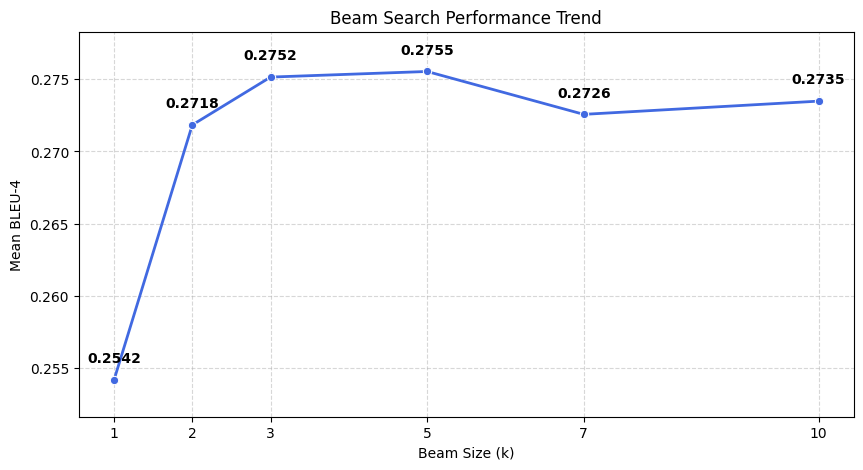

Mean Scores per k:
k
1     0.254154
2     0.271835
3     0.275152
5     0.275540
7     0.272568
10    0.273485
Name: BLEU-4, dtype: float64


In [ ]:
# Reshape data for visualization
melted_df = df_results.melt(
    id_vars=['filename'], 
    value_vars=[f"bleu_k{k}" for k in k_values],
    var_name='k', 
    value_name='BLEU-4'
)
melted_df['k'] = melted_df['k'].str.replace('bleu_k', '').astype(int)

# Plot performance trends
plt.figure(figsize=(10, 5))
sns.lineplot(data=melted_df, x='k', y='BLEU-4', marker='o', color='royalblue', lw=2, errorbar=None)

# Plot annotations
stats = melted_df.groupby('k')['BLEU-4'].mean()
for x, y in stats.items():
    plt.text(x, y + 0.001, f'{y:.4f}', ha='center', va='bottom', weight='bold')

plt.title('Beam Search Performance Trend', fontsize=12)
plt.xlabel('Beam Size (k)')
plt.ylabel('Mean BLEU-4')
plt.xticks(k_values)
plt.grid(True, ls='--', alpha=0.5)
plt.ylim(stats.min() * 0.99, stats.max() * 1.01)
plt.show()

print("Mean Scores per k:")
print(stats)

### Analiza jakościowa: Demonstracja przypadków gdzie jest największa różnica pomiędzy Beam Search a Greedy Search 

Wybieramy 3 obrazy z największą różnicą BLEU-4 między `k=1` a `k=5`. Pokazujemy obok siebie opis Greedy Search i opis z Beam Search - co pozwala ocenić jakie błędy naprawia Beam Search (np. pominięte słowa, urwane zdania, zła kolejność).

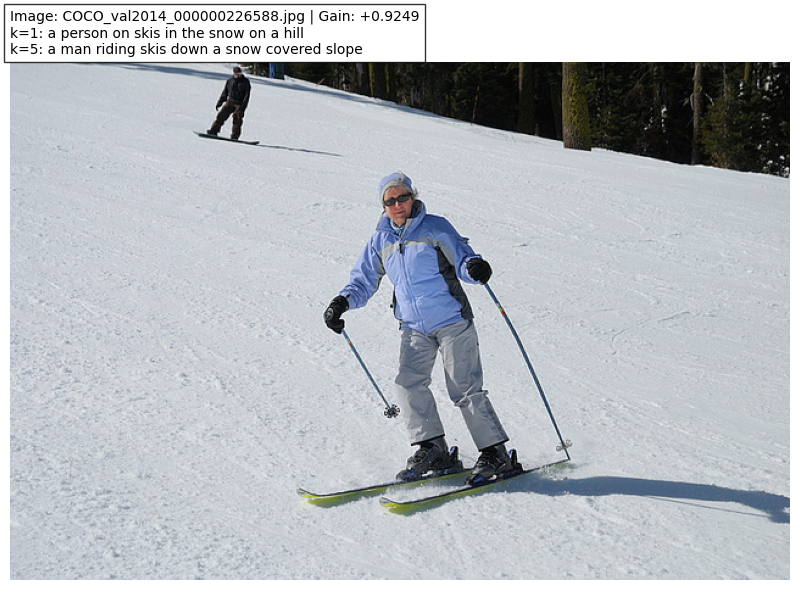

--------------------------------------------------------------------------------


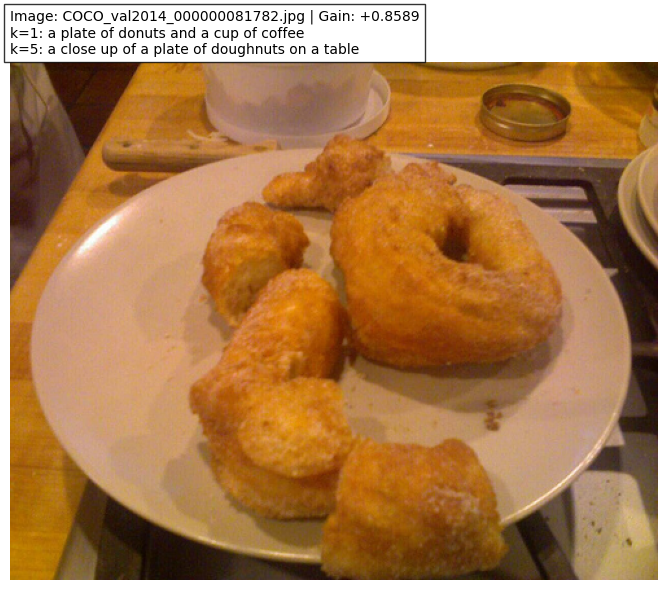

--------------------------------------------------------------------------------


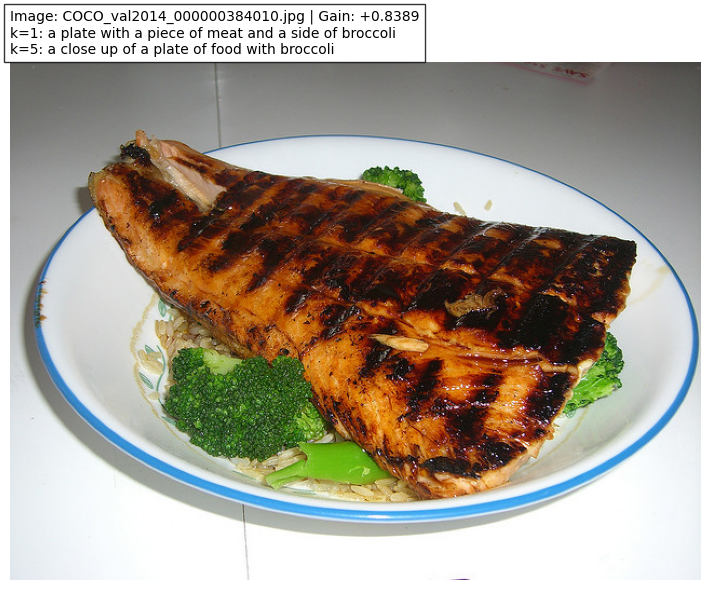

--------------------------------------------------------------------------------


In [ ]:
# Identify top 3 cases where k=5 outperformed k=1
df_results['delta'] = df_results['bleu_k5'] - df_results['bleu_k1']
showcase = df_results.sort_values(by='delta', ascending=False).head(3)

for _, row in showcase.iterrows():
    img = plt.imread(os.path.join("../dataset/val2014", row['filename']))
    
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis('off')
    
    meta = (f"Image: {row['filename']} | Gain: +{row['delta']:.4f}\n"
            f"k=1: {row['cap_k1']}\n"
            f"k=5: {row['cap_k5']}")
    
    plt.title(meta, fontsize=10, loc='left', bbox=dict(facecolor='white', alpha=0.8))
    plt.tight_layout()
    plt.show()
    print("-" * 80)

### Wnioski
**Obserwacje:**
- Beam Search wyraźnie przewyższa Greedy już przy `k=2`
- Dalszy wzrost `k` powyżej 3 nie daje istotnej poprawy
- Dla `k=7` i `k=10` BLEU-4 lekko spada, co sugeruje że model zaczyna preferować
  zdania o wysokim prawdopodobieństwie kosztem dopasowania do referencji
- Optymalny kompromis jakość/koszt: **`k=3`** - używany we wszystkich pozostałych eksperymentach

**Ograniczenia:** BLEU-4 mierzy n-gramowe pokrycie, nie semantykę. Opis poprawny
semantycznie ale inaczej sformułowany dostanie niski BLEU - dlatego analiza
jakościowa jest też ważna.

# Krytyczna analiza
<!-- TODO: (podsumowanie weryfikacji eksperymentalnej) -->

# Wnioski
<!-- głównie w zakresie stosowalności metody na podstawie własnych eksperymentów - kiedy się sprawdza, kiedy nie itd.  -->